# 0050 Lazy Bear Squeeze 回測（更新版）

本 notebook 只保留本次指定內容：

- 回測期間：2016/1/1～2025/12/31
- 標的：0050
- 資料來源：附件 `0050_OHLCV.csv`
- 初始資金：NT$1,000,000
- 進場：只使用 Lazy Bear Squeeze，BB = 2、KC = 1.5
- 交易方式：符合進場訊號即 all in；出場 all out
- 成本：買進與賣出手續費、賣出證交稅
- 策略一：停利 = 1.272 Fibonacci；停損 = 收盤價跌破 21EMA
- 策略二：停利 = +20%；停損 = -15%
- 策略三：Buy & Hold，2016/1/1 後第一個交易日買進，2025/12/31 賣出

績效指標只保留：Total Return (%)、Sharpe Ratio、Max Drawdown (%)、Win Rate (%)、Average Trade Return (%)、Total PnL、Total Cost、Profit Factor、Number of Trades。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("./0050_OHLCV.csv")
START_DATE = "2016-01-01"
END_DATE = "2025-12-31"
INITIAL_CAPITAL = 1_000_000

# 台股常見成本設定：可依券商折扣自行修改
COMMISSION_RATE = 0.001425   # 手續費：0.1425%，買賣各收一次
TAX_RATE = 0.003             # ETF 證交稅：0.1%，只在賣出收取

BB_LENGTH = 20
BB_MULT = 2.0
KC_LENGTH = 20
KC_MULT = 1.5
EMA_LENGTH = 21
TRADING_DAYS = 252

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
def load_0050_ohlcv(path: Path) -> pd.DataFrame:
    """讀取附件 0050_OHLCV.csv，整理為 Date/Open/High/Low/Close/Volume。"""
    df = pd.read_csv(path)
    df = df.rename(columns={
        "年月日": "Date",
        "開盤價(元)": "Open",
        "最高價(元)": "High",
        "最低價(元)": "Low",
        "收盤價(元)": "Close",
        "成交量(千股)": "Volume",
    })
    df["Date"] = pd.to_datetime(df["Date"])
    for col in ["Open", "High", "Low", "Close"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["Volume"] = (
        df["Volume"].astype(str).str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    df = df[["Date", "Open", "High", "Low", "Close", "Volume"]].dropna()
    df = df[(df["Date"] >= START_DATE) & (df["Date"] <= END_DATE)]
    df = df.sort_values("Date").reset_index(drop=True)
    return df

price = load_0050_ohlcv(DATA_PATH)
print(price.head())
print(price.tail())
print(f"資料筆數：{len(price):,}")

        Date    Open    High     Low   Close  Volume
0 2016-01-04 11.0645 11.0918 10.7461 10.8370   16928
1 2016-01-05 10.8279 10.8734 10.7097 10.7461   21783
2 2016-01-06 10.7461 10.7461 10.5368 10.6369   28939
3 2016-01-07 10.6096 10.6096 10.3184 10.4367   39962
4 2016-01-08 10.3730 10.5004 10.3457 10.4549   25450
           Date    Open    High     Low   Close  Volume
2433 2025-12-24 63.0599 63.1586 62.8627 62.9613   64106
2434 2025-12-26 63.3065 63.6023 63.2079 63.5037   70816
2435 2025-12-29 63.7502 64.4405 63.7009 64.3419   86510
2436 2025-12-30 63.9967 64.3912 63.8488 64.2432   61058
2437 2025-12-31 64.1939 64.9335 63.9967 64.6870   71868
資料筆數：2,438


In [3]:
def rolling_linreg_last(values: np.ndarray, length: int) -> pd.Series:
    """計算 Lazy Bear momentum 使用的 rolling linear regression 最後一點。"""
    x = np.arange(length, dtype=float)
    x_mean = x.mean()
    denom = ((x - x_mean) ** 2).sum()

    def linreg(y):
        if np.isnan(y).any():
            return np.nan
        y_mean = y.mean()
        slope = ((x - x_mean) * (y - y_mean)).sum() / denom
        intercept = y_mean - slope * x_mean
        return intercept + slope * (length - 1)

    return pd.Series(values).rolling(length).apply(linreg, raw=True)


def add_lazy_bear_squeeze(df: pd.DataFrame) -> pd.DataFrame:
    """Lazy Bear Squeeze：BB mult=2、KC mult=1.5。"""
    out = df.copy()
    close = out["Close"]
    high = out["High"]
    low = out["Low"]

    # Bollinger Bands
    basis = close.rolling(BB_LENGTH).mean()
    dev = BB_MULT * close.rolling(BB_LENGTH).std(ddof=0)
    upper_bb = basis + dev
    lower_bb = basis - dev

    # Keltner Channels；Lazy Bear 原版常用 True Range
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    range_ma = tr.rolling(KC_LENGTH).mean()
    ma = close.rolling(KC_LENGTH).mean()
    upper_kc = ma + KC_MULT * range_ma
    lower_kc = ma - KC_MULT * range_ma

    # Squeeze 狀態
    out["squeeze_on"] = (lower_bb > lower_kc) & (upper_bb < upper_kc)
    out["squeeze_off"] = (lower_bb < lower_kc) & (upper_bb > upper_kc)
    out["no_squeeze"] = ~(out["squeeze_on"] | out["squeeze_off"])

    # Lazy Bear momentum
    highest_high = high.rolling(KC_LENGTH).max()
    lowest_low = low.rolling(KC_LENGTH).min()
    value_base = ((highest_high + lowest_low) / 2 + close.rolling(KC_LENGTH).mean()) / 2
    raw_value = close - value_base
    out["squeeze_momentum"] = rolling_linreg_last(raw_value.to_numpy(), KC_LENGTH).to_numpy()

    out["EMA21"] = close.ewm(span=EMA_LENGTH, adjust=False).mean()

    # 進場訊號：squeeze 從 on 轉為 off，且 momentum > 0。
    # 這是 Lazy Bear Squeeze 常見的 squeeze release 進場用法。
    out["entry_signal"] = out["squeeze_on"].shift(1).fillna(False) & out["squeeze_off"] & (out["squeeze_momentum"] > 0)
    return out

data = add_lazy_bear_squeeze(price)
data[["Date", "Close", "squeeze_on", "squeeze_off", "squeeze_momentum", "EMA21", "entry_signal"]].tail(10)

,Date,Close,squeeze_on,squeeze_off,squeeze_momentum,EMA21,entry_signal
2428,2025-12-17,61.0385,False,True,1.7968,61.5835,False
2429,2025-12-18,61.0385,False,True,1.6541,61.5340,False
2430,2025-12-19,61.6301,False,True,1.4147,61.5427,False
2431,2025-12-22,62.5176,False,True,1.2324,61.6313,False
2432,2025-12-23,62.8134,False,True,1.0808,61.7388,False
2433,2025-12-24,62.9613,False,True,0.9914,61.8499,False
2434,2025-12-26,63.5037,False,True,1.0254,62.0003,False
2435,2025-12-29,64.3419,False,True,1.1887,62.2132,False
2436,2025-12-30,64.2432,False,True,1.2075,62.3977,False
2437,2025-12-31,64.6870,False,True,1.2886,62.6058,False


In [4]:
def buy_all_in(cash: float, price: float):
    """用所有現金買進整股，買進手續費納入成本。"""
    shares = int(cash // (price * (1 + COMMISSION_RATE)))
    gross = shares * price
    fee = gross * COMMISSION_RATE
    cash_after = cash - gross - fee
    return shares, cash_after, fee


def sell_all(shares: int, price: float):
    """全部賣出，扣除賣出手續費與證交稅。"""
    gross = shares * price
    fee = gross * COMMISSION_RATE
    tax = gross * TAX_RATE
    cash_after = gross - fee - tax
    return cash_after, fee, tax


def backtest_squeeze(df: pd.DataFrame, mode: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    mode='fib_ema': 停利 1.272 Fibonacci；停損收盤跌破 21EMA。
    mode='fixed_pct': 停利 +20%；停損 -15%。
    """
    cash = float(INITIAL_CAPITAL)
    shares = 0
    entry_price = np.nan
    entry_date = None
    total_fees = 0.0
    total_tax = 0.0
    trades = []
    equity_curve = []

    for _, row in df.iterrows():
        date = row["Date"]
        close = float(row["Close"])
        ema21 = float(row["EMA21"])
        signal = bool(row["entry_signal"])

        # 已持有：先檢查出場
        if shares > 0:
            exit_reason = None
            if mode == "fib_ema":
                take_profit_price = entry_price * 1.272
                if close >= take_profit_price:
                    exit_reason = "TP_1.272_Fibonacci"
                elif close < ema21:
                    exit_reason = "SL_Below_21EMA"
            elif mode == "fixed_pct":
                if close >= entry_price * 1.20:
                    exit_reason = "TP_+20%"
                elif close <= entry_price * 0.85:
                    exit_reason = "SL_-15%"
            else:
                raise ValueError("mode must be 'fib_ema' or 'fixed_pct'")

            if exit_reason:
                shares_to_sell = shares
                proceeds, sell_fee, tax = sell_all(shares_to_sell, close)
                cash += proceeds
                total_fees += sell_fee
                total_tax += tax
                pnl = cash - trades[-1]["cash_before_entry"]
                net_return = pnl / trades[-1]["cash_before_entry"]
                trades[-1].update({
                    "exit_date": date,
                    "exit_price": close,
                    "exit_reason": exit_reason,
                    "sell_fee": sell_fee,
                    "tax": tax,
                    "total_cost": trades[-1]["buy_fee"] + sell_fee + tax,
                    "pnl": pnl,
                    "net_return_pct": net_return,
                    "holding_days": (date - entry_date).days,
                    "ending_cash": cash,
                })
                shares = 0
                entry_price = np.nan
                entry_date = None

        # 空手：符合進場訊號就 all in
        if shares == 0 and signal:
            cash_before_entry = cash
            shares, cash, buy_fee = buy_all_in(cash, close)
            if shares > 0:
                total_fees += buy_fee
                entry_price = close
                entry_date = date
                trades.append({
                    "entry_date": date,
                    "entry_price": close,
                    "shares": shares,
                    "cash_before_entry": cash_before_entry,
                    "buy_fee": buy_fee,
                })

        equity = cash + shares * close
        equity_curve.append({
            "Date": date,
            "equity": equity,
            "cash": cash,
            "shares": shares,
            "Close": close,
        })

    # 期末仍持有則以最後一天收盤價強制平倉，方便比較績效
    if shares > 0:
        last = df.iloc[-1]
        close = float(last["Close"])
        date = last["Date"]
        shares_to_sell = shares
        proceeds, sell_fee, tax = sell_all(shares_to_sell, close)
        cash += proceeds
        total_fees += sell_fee
        total_tax += tax
        pnl = cash - trades[-1]["cash_before_entry"]
        net_return = pnl / trades[-1]["cash_before_entry"]
        trades[-1].update({
            "exit_date": date,
            "exit_price": close,
            "exit_reason": "Force_Close_End_Date",
            "sell_fee": sell_fee,
            "tax": tax,
            "total_cost": trades[-1]["buy_fee"] + sell_fee + tax,
            "pnl": pnl,
            "net_return_pct": net_return,
            "holding_days": (date - entry_date).days,
            "ending_cash": cash,
        })
        shares = 0
        equity_curve[-1].update({"equity": cash, "cash": cash, "shares": 0})

    equity_df = pd.DataFrame(equity_curve)
    trades_df = pd.DataFrame(trades)
    equity_df.attrs["total_fees"] = total_fees
    equity_df.attrs["total_tax"] = total_tax
    equity_df.attrs["total_cost"] = total_fees + total_tax
    equity_df.attrs["final_equity"] = float(equity_df["equity"].iloc[-1])
    return equity_df, trades_df


def backtest_buy_and_hold(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """2016/1/1 後第一個交易日 all in 買進，2025/12/31 all out 賣出。"""
    first = df.iloc[0]
    last = df.iloc[-1]
    buy_date = first["Date"]
    sell_date = last["Date"]
    buy_price = float(first["Close"])
    sell_price = float(last["Close"])

    cash_before_entry = float(INITIAL_CAPITAL)
    shares, cash, buy_fee = buy_all_in(cash_before_entry, buy_price)
    equity_curve = []
    for _, row in df.iterrows():
        equity_curve.append({
            "Date": row["Date"],
            "equity": cash + shares * float(row["Close"]),
            "cash": cash,
            "shares": shares,
            "Close": float(row["Close"]),
        })

    shares_to_sell = shares
    proceeds, sell_fee, tax = sell_all(shares_to_sell, sell_price)
    final_cash = cash + proceeds
    pnl = final_cash - cash_before_entry
    net_return = pnl / cash_before_entry

    equity_curve[-1].update({"equity": final_cash, "cash": final_cash, "shares": 0})
    equity_df = pd.DataFrame(equity_curve)
    equity_df.attrs["total_fees"] = buy_fee + sell_fee
    equity_df.attrs["total_tax"] = tax
    equity_df.attrs["total_cost"] = buy_fee + sell_fee + tax
    equity_df.attrs["final_equity"] = float(final_cash)

    trades_df = pd.DataFrame([{
        "entry_date": buy_date,
        "entry_price": buy_price,
        "shares": shares_to_sell,
        "cash_before_entry": cash_before_entry,
        "buy_fee": buy_fee,
        "exit_date": sell_date,
        "exit_price": sell_price,
        "exit_reason": "Sell_End_Date",
        "sell_fee": sell_fee,
        "tax": tax,
        "total_cost": buy_fee + sell_fee + tax,
        "pnl": pnl,
        "net_return_pct": net_return,
        "holding_days": (sell_date - buy_date).days,
        "ending_cash": final_cash,
    }])
    return equity_df, trades_df

In [5]:
def profit_factor_from_trades(trades: pd.DataFrame) -> float:
    if trades.empty or "pnl" not in trades.columns:
        return np.nan
    closed = trades.dropna(subset=["pnl"]).copy()
    if closed.empty:
        return np.nan
    gross_profit = closed.loc[closed["pnl"] > 0, "pnl"].sum()
    gross_loss = -closed.loc[closed["pnl"] < 0, "pnl"].sum()
    if gross_loss == 0:
        return np.inf if gross_profit > 0 else np.nan
    return gross_profit / gross_loss


def sharpe_ratio_from_equity(equity: pd.DataFrame) -> float:
    daily_ret = equity["equity"].pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    if daily_ret.empty or daily_ret.std(ddof=1) == 0:
        return np.nan
    return (daily_ret.mean() / daily_ret.std(ddof=1)) * np.sqrt(TRADING_DAYS)


def summarize_performance(name: str, equity: pd.DataFrame, trades: pd.DataFrame) -> dict:
    final_equity = equity.attrs["final_equity"]
    total_return = final_equity / INITIAL_CAPITAL - 1
    running_max = equity["equity"].cummax()
    drawdown = equity["equity"] / running_max - 1
    max_dd = drawdown.min()

    closed = trades.dropna(subset=["exit_date"]).copy() if not trades.empty else trades
    win_rate = (closed["pnl"] > 0).mean() if not closed.empty else np.nan
    avg_trade_return = closed["net_return_pct"].mean() if not closed.empty else np.nan

    return {
        "Strategy": name,
        "Total Return (%)": total_return * 100,
        "Sharpe Ratio": sharpe_ratio_from_equity(equity),
        "Max Drawdown (%)": max_dd * 100,
        "Win Rate (%)": win_rate * 100 if pd.notna(win_rate) else np.nan,
        "Average Trade Return (%)": avg_trade_return * 100 if pd.notna(avg_trade_return) else np.nan,
        "Total PnL": final_equity - INITIAL_CAPITAL,
        "Total Cost": equity.attrs["total_cost"],
        "Profit Factor": profit_factor_from_trades(closed),
        "Number of Trades": len(closed),
    }

fib_equity, fib_trades = backtest_squeeze(data, mode="fib_ema")
fixed_equity, fixed_trades = backtest_squeeze(data, mode="fixed_pct")
bh_equity, bh_trades = backtest_buy_and_hold(data)

summary = pd.DataFrame([
    summarize_performance("Squeeze + TP 1.272 Fib / SL 21EMA", fib_equity, fib_trades),
    summarize_performance("Squeeze + TP +20% / SL -15%", fixed_equity, fixed_trades),
    summarize_performance("Buy & Hold 0050", bh_equity, bh_trades),
])

summary

,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%),Win Rate (%),Average Trade Return (%),Total PnL,Total Cost,Profit Factor,Number of Trades
0,Squeeze + TP 1.272 Fib / SL 21EMA,34.3141,0.6123,-9.6636,66.6667,3.5398,"343,141.0983","63,415.1524",3.5878,9
1,Squeeze + TP +20% / SL -15%,65.5757,0.4951,-28.3339,71.4286,8.9853,"655,757.4136","68,642.4843",1.8774,7
2,Buy & Hold 0050,493.4210,1.0730,-33.9568,100.0000,493.4210,"4,934,209.6976","27,798.5524",inf,1


In [6]:
summary_display = summary.copy()
for col in ["Total Return (%)", "Max Drawdown (%)", "Win Rate (%)", "Average Trade Return (%)"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:,.2f}%" if pd.notna(x) else "")
for col in ["Sharpe Ratio", "Profit Factor"]:
    summary_display[col] = summary_display[col].map(lambda x: "∞" if np.isinf(x) else (f"{x:,.4f}" if pd.notna(x) else ""))
for col in ["Total PnL", "Total Cost"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:,.0f}")
summary_display[ [
    "Strategy",
    "Total Return (%)",
    "Sharpe Ratio",
    "Max Drawdown (%)",
    "Win Rate (%)",
    "Average Trade Return (%)",
    "Total PnL",
    "Total Cost",
    "Profit Factor",
    "Number of Trades",
] ]

,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%),Win Rate (%),Average Trade Return (%),Total PnL,Total Cost,Profit Factor,Number of Trades
0,Squeeze + TP 1.272 Fib / SL 21EMA,34.31%,0.6123,-9.66%,66.67%,3.54%,"343,141","63,415",3.5878,9
1,Squeeze + TP +20% / SL -15%,65.58%,0.4951,-28.33%,71.43%,8.99%,"655,757","68,642",1.8774,7
2,Buy & Hold 0050,493.42%,1.0730,-33.96%,100.00%,493.42%,"4,934,210","27,799",∞,1


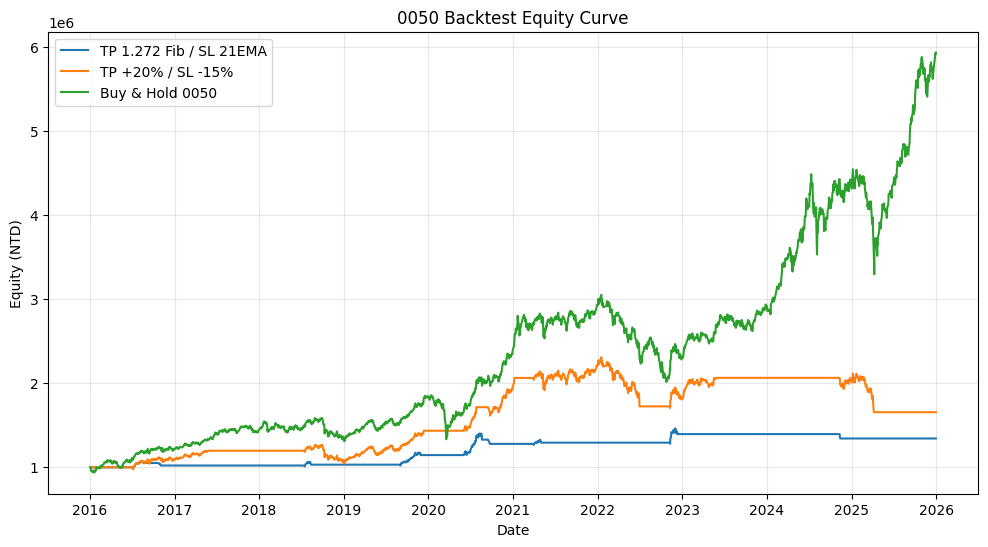

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(fib_equity["Date"], fib_equity["equity"], label="TP 1.272 Fib / SL 21EMA")
plt.plot(fixed_equity["Date"], fixed_equity["equity"], label="TP +20% / SL -15%")
plt.plot(bh_equity["Date"], bh_equity["equity"], label="Buy & Hold 0050")
plt.title("0050 Backtest Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity (NTD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
print("策略一交易紀錄：TP 1.272 Fibonacci / SL 21EMA")
fib_trades

策略一交易紀錄：TP 1.272 Fibonacci / SL 21EMA


,entry_date,entry_price,shares,cash_before_entry,buy_fee,exit_date,exit_price,exit_reason,sell_fee,tax,total_cost,pnl,net_return_pct,holding_days,ending_cash
0,2016-07-01,12.0563,82826,"1,000,000.0000","1,422.9695",2016-08-19,12.7486,SL_Below_21EMA,"1,504.6796","3,167.7466","6,095.3958","51,245.0440",0.0512,49,"1,051,245.0440"
1,2016-10-25,13.5224,77630,"1,051,245.0440","1,495.8851",2016-11-02,13.2184,SL_Below_21EMA,"1,462.2558","3,078.4332","6,036.5740","-29,636.0940",-0.0282,8,"1,021,608.9500"
2,2018-07-13,16.2643,62723,"1,021,608.9500","1,453.7076",2018-08-13,16.5179,SL_Below_21EMA,"1,476.3744","3,108.1567","6,038.2388","9,868.3140",0.0097,31,"1,031,477.2640"
3,2019-09-02,16.7559,61471,"1,031,477.2640","1,467.7527",2019-11-29,18.7199,SL_Below_21EMA,"1,639.7916","3,452.1929","6,559.7373","114,169.3067",0.1107,88,"1,145,646.5707"
4,2020-06-03,18.3354,62393,"1,145,646.5707","1,630.2009",2020-08-20,21.4049,SL_Below_21EMA,"1,903.1102","4,006.5478","7,539.8588","183,975.4547",0.1606,78,"1,329,622.0254"
5,2020-09-16,22.6708,58565,"1,329,622.0254","1,891.9944",2020-09-22,21.9368,SL_Below_21EMA,"1,830.7384","3,854.1861","7,576.9189","-50,563.6289",-0.0380,6,"1,279,058.3965"
6,2021-03-30,29.5459,43228,"1,279,058.3965","1,820.0245",2021-05-03,30.0568,SL_Below_21EMA,"1,851.4959","3,897.8861","7,569.4064","14,515.7788",0.0113,34,"1,293,574.1752"
7,2022-11-09,23.6454,54629,"1,293,574.1752","1,840.7075",2022-12-13,25.6592,SL_Below_21EMA,"1,997.4744","4,205.2093","8,043.3912","101,968.4890",0.0788,34,"1,395,542.6642"
8,2024-11-11,48.0719,28989,"1,395,542.6642","1,985.8177",2024-11-13,46.5387,SL_Below_21EMA,"1,922.4823","4,047.3311","7,955.6311","-52,401.5659",-0.0375,2,"1,343,141.0983"


In [9]:
print("策略二交易紀錄：TP +20% / SL -15%")
fixed_trades

策略二交易紀錄：TP +20% / SL -15%


,entry_date,entry_price,shares,cash_before_entry,buy_fee,exit_date,exit_price,exit_reason,sell_fee,tax,total_cost,pnl,net_return_pct,holding_days,ending_cash
0,2016-07-01,12.0563,82826,"1,000,000.0000","1,422.9695",2017-05-25,14.5224,TP_+20%,"1,714.0360","3,608.4969","6,745.5025","197,511.6961",0.1975,328,"1,197,511.6961"
1,2018-07-13,16.2643,73523,"1,197,511.6961","1,704.0152",2019-12-12,19.6099,TP_+20%,"2,054.5346","4,325.3360","8,083.8858","237,894.6630",0.1987,517,"1,435,406.3591"
2,2020-06-03,18.3354,78174,"1,435,406.3591","2,042.5260",2020-07-28,22.0432,TP_+20%,"2,455.5673","5,169.6154","9,667.7086","280,185.8486",0.1952,55,"1,715,592.2077"
3,2020-09-16,22.6708,75566,"1,715,592.2077","2,441.2269",2021-01-07,27.4263,TP_+20%,"2,953.3065","6,217.4874","11,612.0207","347,742.0923",0.2027,113,"2,063,334.3000"
4,2021-03-30,29.5459,69735,"2,063,334.3000","2,936.0463",2022-07-01,24.8473,SL_-15%,"2,469.1352","5,198.1794","10,603.3609","-338,260.2319",-0.1639,458,"1,725,074.0681"
5,2022-11-09,23.6454,72852,"1,725,074.0681","2,454.7259",2023-05-25,28.4695,TP_+20%,"2,955.5355","6,222.1800","11,632.4415","339,812.8917",0.1970,197,"2,064,886.9598"
6,2024-11-11,48.0719,42893,"2,064,886.9598","2,938.2759",2025-04-07,38.7736,SL_-15%,"2,369.9403","4,989.3481","10,297.5643","-409,129.5462",-0.1981,147,"1,655,757.4136"


In [10]:
print("Buy & Hold 0050 交易紀錄")
bh_trades

Buy & Hold 0050 交易紀錄


,entry_date,entry_price,shares,cash_before_entry,buy_fee,exit_date,exit_price,exit_reason,sell_fee,tax,total_cost,pnl,net_return_pct,holding_days,ending_cash
0,2016-01-04,10.8370,92145,"1,000,000.0000","1,422.9699",2025-12-31,64.6870,Sell_End_Date,"8,493.8317","17,881.7508","27,798.5524","4,934,209.6976",4.9342,3649,"5,934,209.6976"


In [11]:
# 輸出結果，方便後續檢查
OUTPUT_DIR = Path("/mnt/data/0050_squeeze_clean_backtest_outputs_updated")
OUTPUT_DIR.mkdir(exist_ok=True)
summary.to_csv(OUTPUT_DIR / "summary.csv", index=False, encoding="utf-8-sig")
fib_trades.to_csv(OUTPUT_DIR / "fib_ema_trades.csv", index=False, encoding="utf-8-sig")
fixed_trades.to_csv(OUTPUT_DIR / "fixed_pct_trades.csv", index=False, encoding="utf-8-sig")
bh_trades.to_csv(OUTPUT_DIR / "buy_hold_trades.csv", index=False, encoding="utf-8-sig")
fib_equity.to_csv(OUTPUT_DIR / "fib_ema_equity.csv", index=False, encoding="utf-8-sig")
fixed_equity.to_csv(OUTPUT_DIR / "fixed_pct_equity.csv", index=False, encoding="utf-8-sig")
bh_equity.to_csv(OUTPUT_DIR / "buy_hold_equity.csv", index=False, encoding="utf-8-sig")
print(f"已輸出至：{OUTPUT_DIR}")

已輸出至：\mnt\data\0050_squeeze_clean_backtest_outputs_updated
